In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


In [3]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

In [4]:
train_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = ToTensor(),
    target_transform = None
)

test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = ToTensor()
)

In [5]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
image.shape

torch.Size([1, 28, 28])

In [7]:
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [8]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Image Shape = torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

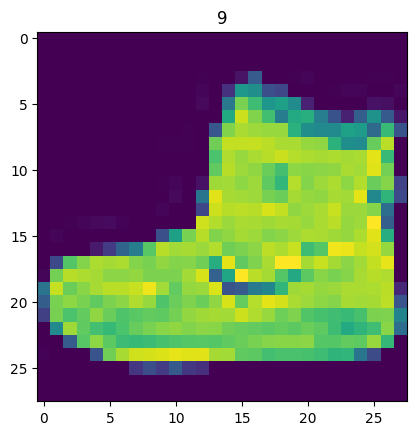

In [9]:
image, label = train_data[0]
print(f'Image Shape = {image.shape}')
plt.imshow(image.squeeze())
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

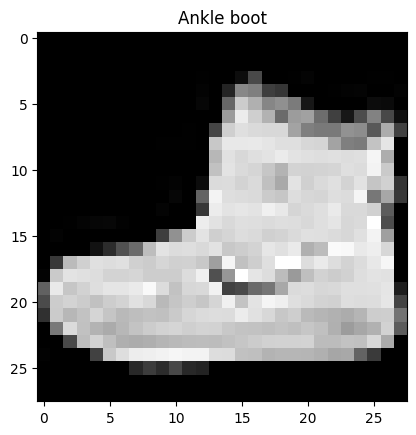

In [10]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(train_data.classes[label])

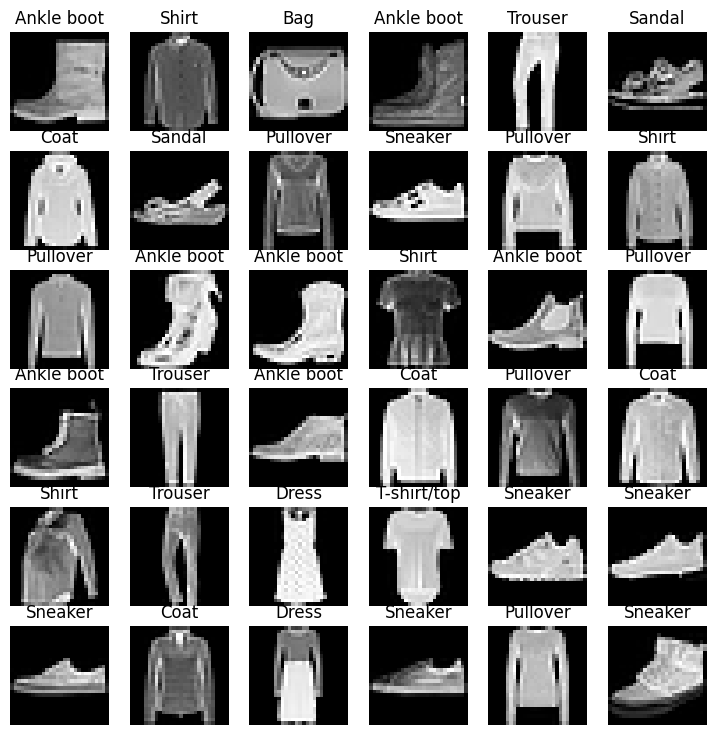

In [11]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 6,6
for i in range(1, rows*cols + 1):
    random_idx = torch.randint(0, len(train_data), size = [1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(),cmap = 'gray')
    plt.title(train_data.classes[label])
    plt.axis(False)


In [12]:
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                               batch_size = BATCH_SIZE,
                               shuffle = True)

test_dataloader = DataLoader(test_data,
                              batch_size = BATCH_SIZE,
                              shuffle = False)

train_dataloader, test_dataloader, len(train_dataloader), len(test_dataloader)

(<torch.utils.data.dataloader.DataLoader at 0x231fc0a7080>,
 1875,
 313)

In [15]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [16]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)
x.shape, output.shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]))

In [50]:
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_features: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape, out_features = hidden_features),
            nn.Linear(in_features = hidden_features, out_features = output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)
        
        

In [51]:
torch.manual_seed(42)

model_0 = FashionMNISTModelV0(input_shape=784, 
    hidden_features=10, 
    output_shape=len(train_data.classes) 
)

In [52]:
import requests
from pathlib import Path 

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download


In [53]:
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [54]:
from timeit import default_timer as timer
def print_train_time(start : float, end : float, device: torch.device = None):
    total_time = end - start
    print(total_time)
    return total_time

In [56]:
from tqdm.auto import tqdm

torch.manual_seed(42)
train_time_start_on_cpu = timer()

epochs = 5

for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n----------')
    train_loss = 0
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
        train_loss /= len(train_dataloader)

        test_loss, test_acc = 0,0
        model_0.eval()
        with torch.inference_mode():
            for X, y in test_dataloader:
                test_pred = model_0(X)
                test_loss += loss_fn(test_pred, y) 
                test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
            test_loss /= len(test_dataloader)
            test_acc /= len(test_dataloader)
        print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")    
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters()).device))


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
----------
Looked at 0/60000 samples

Train loss: 0.00056 | Test loss: 1.09149, Test acc: 62.15%


Train loss: 0.00061 | Test loss: 1.07219, Test acc: 65.34%


Train loss: 0.00059 | Test loss: 1.03350, Test acc: 66.72%


Train loss: 0.00053 | Test loss: 1.02836, Test acc: 64.22%


Train loss: 0.00046 | Test loss: 1.00062, Test acc: 63.80%


Train loss: 0.00045 | Test loss: 0.99412, Test acc: 63.91%


Train loss: 0.00048 | Test loss: 0.97100, Test acc: 66.84%


Train loss: 0.00055 | Test loss: 1.05140, Test acc: 60.68%


Train loss: 0.00052 | Test loss: 0.97108, Test acc: 64.89%


Train loss: 0.00047 | Test loss: 0.96862, Test acc: 63.85%


Train loss: 0.00050 | Test loss: 0.95120, Test acc: 67.09%


Train loss: 0.00053 | Test loss: 1.01398, Test acc: 62.36%


Train loss: 0.00055 | Test loss: 0.93548, Test acc: 66.77%


Train loss: 0.00057 | Test loss: 0.93677, Test acc: 64.72%


Train loss: 0.00050 | Test loss: 0.97112, Test acc: 65.59%


Train loss: 0.00049 | Test loss: 0.961

 20%|██        | 1/5 [33:40<2:14:40, 2020.14s/it]


Train loss: 0.00025 | Test loss: 0.50871, Test acc: 82.13%

Epoch: 1
----------
Looked at 0/60000 samples

Train loss: 0.00024 | Test loss: 0.51102, Test acc: 82.33%


Train loss: 0.00024 | Test loss: 0.51775, Test acc: 81.55%


Train loss: 0.00014 | Test loss: 0.50499, Test acc: 82.41%


Train loss: 0.00027 | Test loss: 0.50522, Test acc: 82.55%


Train loss: 0.00030 | Test loss: 0.53440, Test acc: 81.13%


Train loss: 0.00027 | Test loss: 0.62381, Test acc: 77.69%


Train loss: 0.00034 | Test loss: 0.53300, Test acc: 80.85%


Train loss: 0.00028 | Test loss: 0.60712, Test acc: 76.96%


Train loss: 0.00028 | Test loss: 0.54172, Test acc: 80.86%


Train loss: 0.00034 | Test loss: 0.55665, Test acc: 80.98%


Train loss: 0.00028 | Test loss: 0.54729, Test acc: 80.64%


Train loss: 0.00016 | Test loss: 0.49624, Test acc: 82.56%


Train loss: 0.00017 | Test loss: 0.50670, Test acc: 82.34%


Train loss: 0.00030 | Test loss: 0.51230, Test acc: 82.05%


Train loss: 0.00031 | Test loss: 0.530

 40%|████      | 2/5 [1:04:22<1:35:47, 1915.73s/it]

...


Train loss: 0.00019 | Test loss: 0.46935, Test acc: 83.31%

Epoch: 3
----------
Looked at 0/60000 samples

Train loss: 0.00018 | Test loss: 0.47043, Test acc: 83.21%


Train loss: 0.00017 | Test loss: 0.48828, Test acc: 82.76%


Train loss: 0.00013 | Test loss: 0.47562, Test acc: 83.46%


Train loss: 0.00029 | Test loss: 0.46388, Test acc: 83.90%


Train loss: 0.00022 | Test loss: 0.45543, Test acc: 83.86%


Train loss: 0.00008 | Test loss: 0.47292, Test acc: 83.11%


Train loss: 0.00015 | Test loss: 0.48930, Test acc: 82.91%


Train loss: 0.00027 | Test loss: 0.46591, Test acc: 83.61%


Train loss: 0.00026 | Test loss: 0.46625, Test acc: 83.46%


Train loss: 0.00015 | Test loss: 0.45950, Test acc: 83.94%


Train loss: 0.00024 | Test loss: 0.48690, Test acc: 83.07%


Train loss: 0.00039 | Test loss: 0.49655, Test acc: 82.31%


Train loss: 0.00024 | Test loss: 0.46022, Test acc: 83.90%


Train loss: 0.00016 | Test loss: 0.48358, Test acc: 83.09%


Train loss: 0.00016 | Test loss: 0.480

 80%|████████  | 4/5 [2:04:41<30:49, 1849.75s/it]  


Train loss: 0.00021 | Test loss: 0.47871, Test acc: 83.23%

Epoch: 4
----------
Looked at 0/60000 samples

Train loss: 0.00028 | Test loss: 0.52858, Test acc: 81.54%


Train loss: 0.00029 | Test loss: 0.47358, Test acc: 83.64%


Train loss: 0.00042 | Test loss: 0.46567, Test acc: 83.85%


Train loss: 0.00018 | Test loss: 0.45800, Test acc: 83.91%


Train loss: 0.00024 | Test loss: 0.45728, Test acc: 83.94%


Train loss: 0.00036 | Test loss: 0.46613, Test acc: 83.76%


Train loss: 0.00021 | Test loss: 0.46448, Test acc: 83.56%


Train loss: 0.00011 | Test loss: 0.46198, Test acc: 83.71%


Train loss: 0.00039 | Test loss: 0.47719, Test acc: 83.06%


Train loss: 0.00022 | Test loss: 0.47100, Test acc: 83.41%


Train loss: 0.00008 | Test loss: 0.46462, Test acc: 83.77%


Train loss: 0.00023 | Test loss: 0.47095, Test acc: 83.69%


Train loss: 0.00021 | Test loss: 0.45962, Test acc: 84.02%


Train loss: 0.00010 | Test loss: 0.46328, Test acc: 83.70%


Train loss: 0.00027 | Test loss: 0.489

100%|██████████| 5/5 [2:32:42<00:00, 1832.52s/it]


Train loss: 0.00032 | Test loss: 0.46531, Test acc: 83.51%

9162.624047399999
